In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn.functional as F
from groupy import *
from matplotlib.patches import Polygon

# R^2/Z_2 Visualization

## Load data and compute embedded data

In [63]:
N = 1000

# Set device
device = torch.device('cpu')

# Load trained parameters
templates_np = np.load('templates128_trained.npy')
L_np = np.load('L_trained128.npy')

templates = torch.from_numpy(templates_np).float().to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

# Load your input X (shape: d x n)
X_np = np.random.normal(1, 1, size=(2, N))
X = torch.from_numpy(X_np).float().to(device)

# Define your group (use the same pmId you used in training)
G = GPU_GroupAction(pmId, X.shape[0], device=device, dtype=torch.float32)
X_orbits = G.get_orbits(X)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = max_filter(norm_templates, X_orbits)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

# Visualize in 3D using PCA

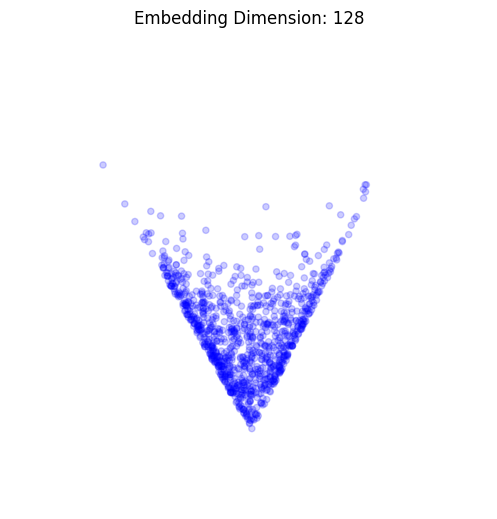

In [78]:
# X_np: original input, shape (2, n_samples)
# Y: model output, shape (target_dim, n_samples)
Y_T = Y.T  # shape: (n_samples, target_dim)

# PCA for Y to 3D
n_comp_Y = min(3, Y_T.shape[0], Y_T.shape[1])
pca_Y = PCA(n_components=n_comp_Y)
Y_pca = pca_Y.fit_transform(Y_T)
if Y_pca.shape[1] < 3:
    padded = np.zeros((Y_pca.shape[0], 3))
    padded[:, :Y_pca.shape[1]] = Y_pca
    Y_pca = padded

# Side-by-side scatterplots
ax = plt.figure(figsize = (5,5)).add_subplot(projection='3d')
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], Y_pca[:, 2], c='blue', alpha=0.2)
ax.view_init(elev=50 ,azim=170)
ax.set_axis_off()
ax.set_title("Embedding Dimension: 128")
plt.tight_layout(pad=0)
plt.savefig("Z2_ed128.png")

# Visualizing Districts 

## Load district outlines and compute embedded data

In [81]:
districts = np.load('district_outlines.npy')

device = torch.device('cpu')

# Load trained parameters
templates_np = np.load('templates_trained_districts.npy')
L_np = np.load('L_trained_districts.npy')

templates = torch.from_numpy(templates_np).to(torch.complex64).to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

X = torch.from_numpy(districts).to(torch.complex64).to(device)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = shape_max_filter(norm_templates, X)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

# Visualize Districts with PCA

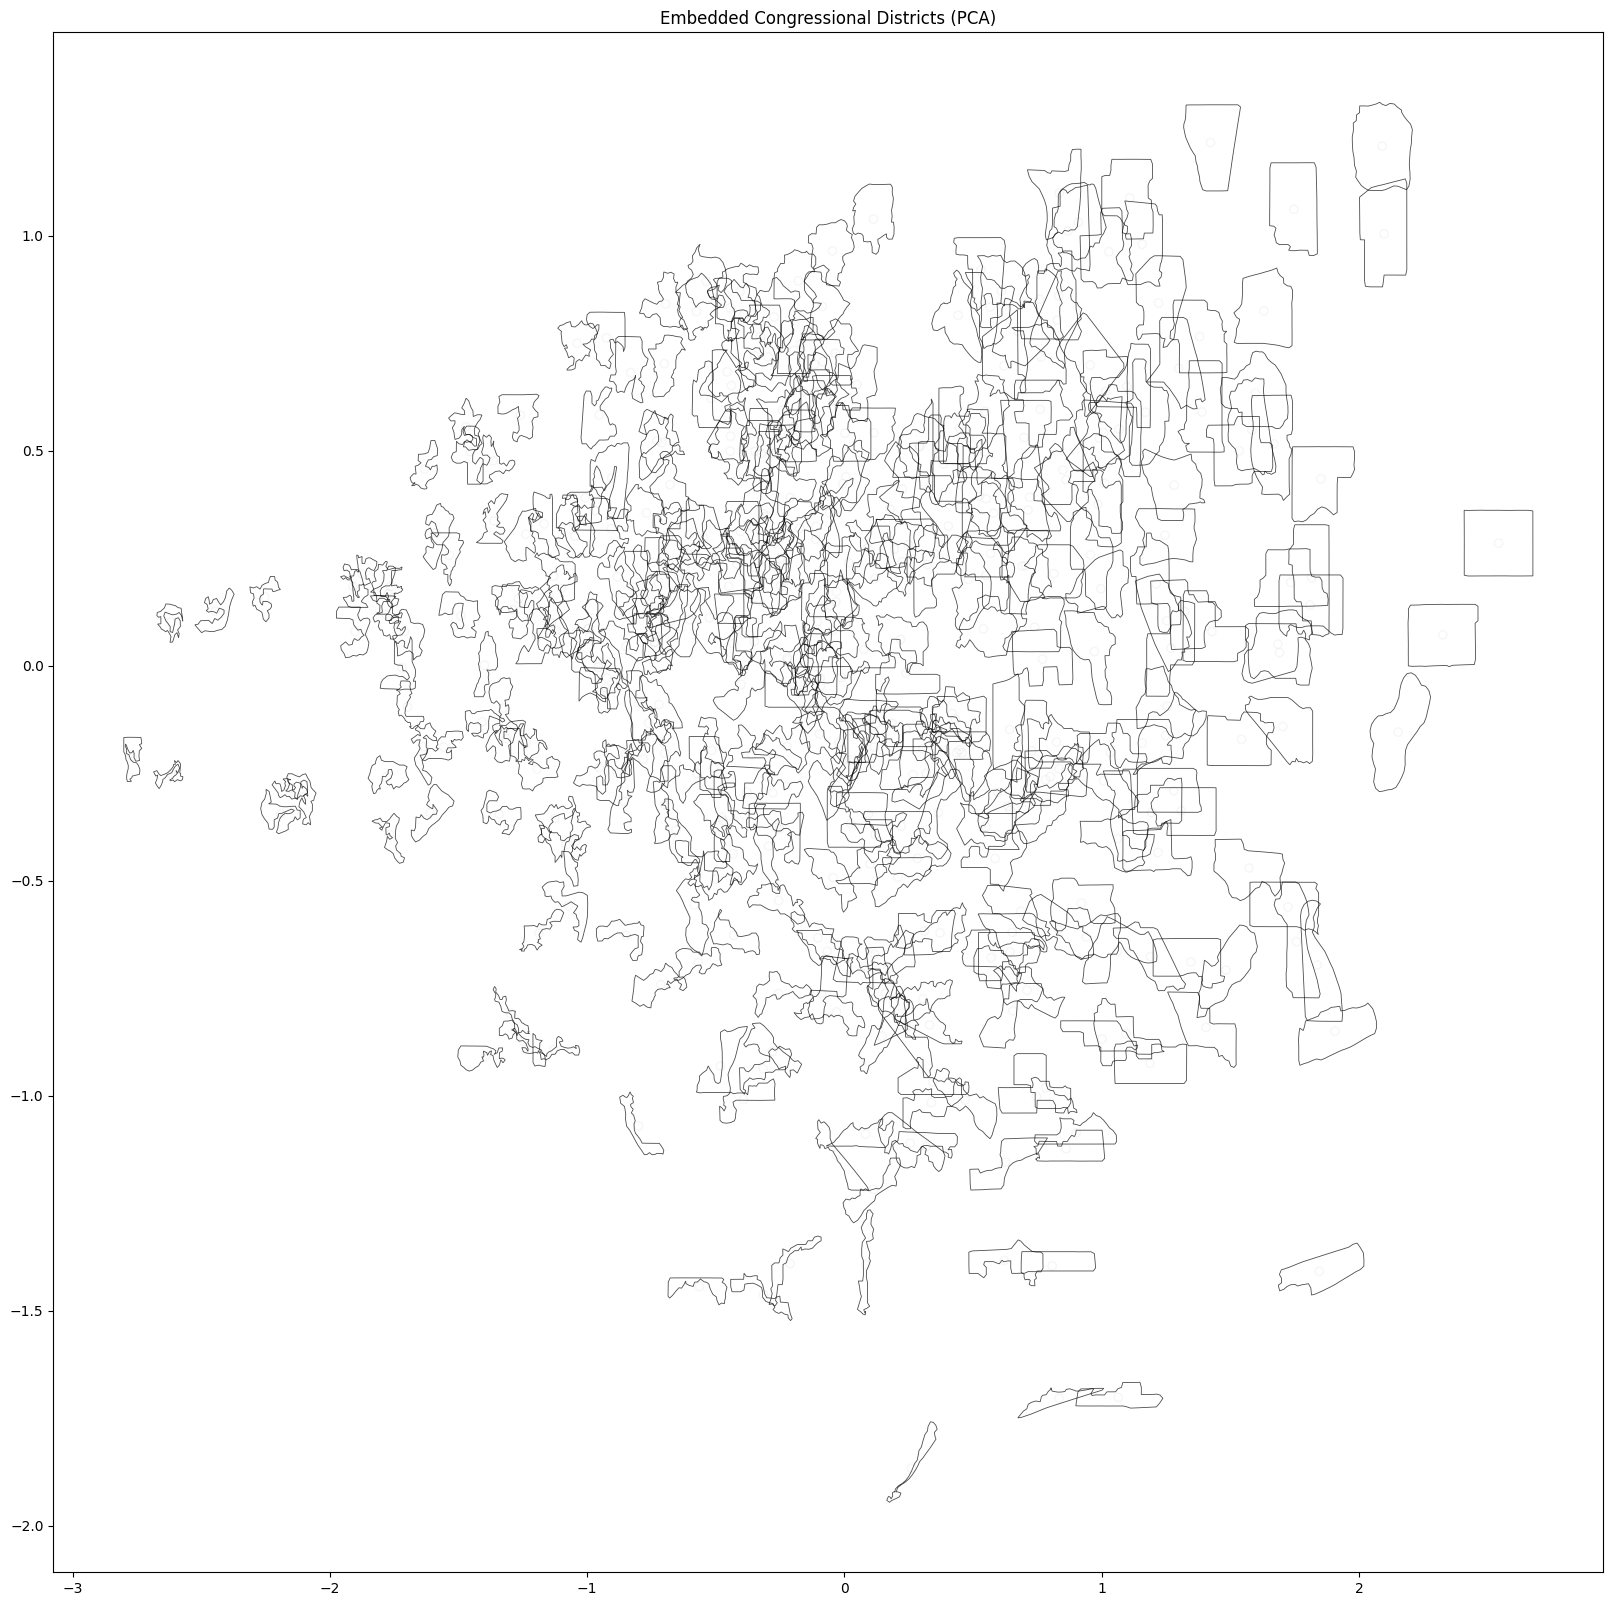

In [84]:
districts_coords = districts.T

def place_complex_outline(ax, pca_point, complex_coords, shape_scale=1,
                          edgecolor='k', alpha=0.8, linewidth=0.5):
    """Draw polygon from complex coords centered & scaled at pca_point."""
    arr = np.asarray(complex_coords)
    if arr.ndim == 1 and np.iscomplexobj(arr):
        verts = np.vstack([arr.real, arr.imag]).T
    elif arr.ndim == 2 and arr.shape[1] == 2:
        verts = arr.astype(float)
    else:
        raise ValueError("complex_coords must be 1D complex or (N,2) real array")

    centroid = verts.mean(axis=0)
    verts = (verts - centroid) * shape_scale + np.asarray(pca_point)[None, :]
    poly = Polygon(verts, closed=True, facecolor='none',
                   edgecolor=edgecolor, alpha=alpha, linewidth=linewidth)
    ax.add_patch(poly)
    return poly

# --- usage (minimal) ---
# Y: shape (features, samples); districts_coords: list/array of complex arrays
Y_T = Y.T
pca = PCA(n_components=2)
Y_pca = pca.fit_transform(Y_T)

fig, ax = plt.subplots(figsize=(20, 20))
ax.scatter(Y_pca[:, 0], Y_pca[:, 1], facecolors='none', edgecolors='lightgray', alpha=0.2)

# scale based on PCA spread (matches your original approach)
pca_ranges = Y_pca.max(0) - Y_pca.min(0)
shape_scale = np.mean(pca_ranges) * .2

subset_fraction = 1
n = Y_pca.shape[0]
subset_idx = np.random.choice(n, max(1, int(n * subset_fraction)), replace=False)

for i in subset_idx:
    place_complex_outline(ax, Y_pca[i, :2], districts_coords[i],
                          shape_scale=shape_scale, edgecolor='k', alpha=0.7, linewidth=0.6)

# automatic margins instead of hard-coded limits
x0, x1 = Y_pca[:,0].min(), Y_pca[:,0].max()
y0, y1 = Y_pca[:,1].min(), Y_pca[:,1].max()
# ax.set_xlim(x0 - 0.1*(x1-x0), x1 + 0.1*(x1-x0))
# ax.set_ylim(y0 - 0.1*(y1-y0), y1 + 0.1*(y1-y0))

ax.set_title("Embedded Congressional Districts (PCA)")
plt.savefig("district_embeddings.png", dpi=300, bbox_inches='tight')
plt.show()